# Stage 7: Rat GeneCompass Initialization and Fine-Tuning

## Stage Objective

Extend the pretrained GeneCompass model to rat genes and optimize it on a mixed-species corpus while retaining transferable human-mouse representations.

## Workflow

| Step | Operation | Analytical purpose |
|------|-----------|--------------------|
| 1 | Checkpoint extension | Expand the vocabulary and initialize rat token and species representations according to ortholog tier. |
| 2 | Frozen-encoder training | Train new embeddings and prior-knowledge projections while holding Transformer layers fixed. |
| 3 | Full-model training | Unfreeze the encoder and continue optimization at a lower learning rate. |
| 4 | Training audit | Evaluate loss trajectories, species composition, checkpoints, and final model files. |

## Inputs and Outputs

| Component | Description |
|-----------|-------------|
| Inputs | Stages 3, 5, and 6 outputs and the pretrained GeneCompass checkpoint. |
| Primary outputs | The extended initialization checkpoint and final rat-fine-tuned model under `data/models/`. |

## Result Overview

The vocabulary is expanded to 55,275 entries and both training phases complete with stable end-of-run loss trajectories.

The sections below present the computational evidence in execution order. All reported figures are generated from the recorded stage outputs rather than manually entered plotting values unless explicitly identified as configuration constants.


In [ ]:
import os, json

MODELS_BASE = '../data/models'
outputs = {
    'rat_genecompass_init/':                 'Step 1 — extended checkpoint (55,275 vocab)',
    'rat_genecompass_finetuned/models/rat_phase1_freeze_mixed/models/': 'Phase 1 — final model',
    'rat_genecompass_finetuned/models/rat_phase2_mixed_species/models/': 'Phase 2 — final model',
}
print(f"{'Path':<65} {'Size':>8}  Notes")
print('-' * 90)
for rel, desc in outputs.items():
    full = f'{MODELS_BASE}/{rel}'
    if os.path.isdir(full):
        total_b = 0
        for dirpath, _, fnames in os.walk(full):
            for fname in fnames:
                try: total_b += os.path.getsize(os.path.join(dirpath, fname))
                except: pass
        print(f"✓ {rel:<63} {total_b/1e9:>7.2f}G  {desc}")
    else:
        print(f"✗ {rel:<63} {'N/A':>8}  {desc}")
print()
# Checkpoint inventory for Phase 2
ckpt_dir = f'{MODELS_BASE}/rat_genecompass_finetuned/models/rat_phase2_mixed_species'
ckpts = sorted([d for d in os.listdir(ckpt_dir) if d.startswith('checkpoint-')])
print(f"Phase 2 checkpoints saved ({len(ckpts)}):")
for ck in ckpts:
    ck_path = f'{ckpt_dir}/{ck}'
    size_b = os.path.getsize(f'{ck_path}/pytorch_model.bin')
    print(f"  {ck:<30} {size_b/1e9:.2f} GB")


Path                                                                  Size  Notes
------------------------------------------------------------------------------------------
✓ rat_genecompass_init/                                              1.39G  Step 1 — extended checkpoint (55,275 vocab)
✓ rat_genecompass_finetuned/models/rat_phase1_freeze_mixed/models/    1.22G  Phase 1 — final model
✓ rat_genecompass_finetuned/models/rat_phase2_mixed_species/models/    1.22G  Phase 2 — final model

Phase 2 checkpoints saved (5):
  checkpoint-110000              1.22 GB
  checkpoint-120000              1.22 GB
  checkpoint-130000              1.22 GB
  checkpoint-140000              1.22 GB
  checkpoint-147941              1.22 GB


## Step 1 — Checkpoint Extension (`rat_model_init.py`)

GeneCompass_Base was pre-trained on 120M+ human and mouse cells with a **50,558-token vocabulary**.
Stage 7 Step 1 extends this checkpoint to accommodate **22,213 rat genes** using 55,275 tokens total.

### Initialization strategy (from `rat_finetune.yaml`)

| Component | Strategy | Rationale |
|-----------|----------|-----------|
| T1–T3 word embeddings | **Copy** from human/mouse ortholog token | Warm start — leverages evolutionary similarity |
| T4 word embeddings | **Random** (N(0, 0.02)) | No ortholog → must learn from scratch |
| T3 warm-start noise | N(0, 0.001) added | Break symmetry between paralogs |
| Species embedding (rat) | **Mouse + noise** N(0, 0.02) | Rat closer to mouse phylogenetically |
| Co-expression matrix | Copy + **rescale × 3.9** | Compensate for cross-species PCC scale |
| Gene family matrix | Copy as-is | Scale-invariant |
| Promoter matrix | Copy as-is | DNABert representations already normalized |
| GRN matrix | Copy as-is | PECA2vec trained once, universally scaled |

The rescale factor 3.9 for co-expression was tuned empirically to match the magnitude
of the human GeneCompass co-expression embedding matrix.


In [ ]:
import json
with open('../data/models/rat_genecompass_init/config.json') as f:
    cfg = json.load(f)
print("rat_genecompass_init/config.json")
print("-" * 40)
for k, v in cfg.items():
    print(f"  {k:<35}: {v}")


rat_genecompass_init/config.json
----------------------------------------
  architectures                      : ['BertForMaskedLM']
  attention_probs_dropout_prob       : 0.02
  classifier_dropout                 : None
  concat_values_first                : False
  emb_warmup_steps                   : 10000
  hidden_act                         : gelu
  hidden_dropout_prob                : 0.02
  hidden_size                        : 768
  initializer_range                  : 0.02
  intermediate_size                  : 3072
  layer_norm_eps                     : 1e-12
  max_position_embeddings            : 2048
  model_type                         : bert
  num_attention_heads                : 12
  num_hidden_layers                  : 12
  pad_token_id                       : 0
  position_embedding_type            : absolute
  torch_dtype                        : float32
  transformers_version               : 4.30.0
  type_vocab_size                    : 2
  use_cache                   

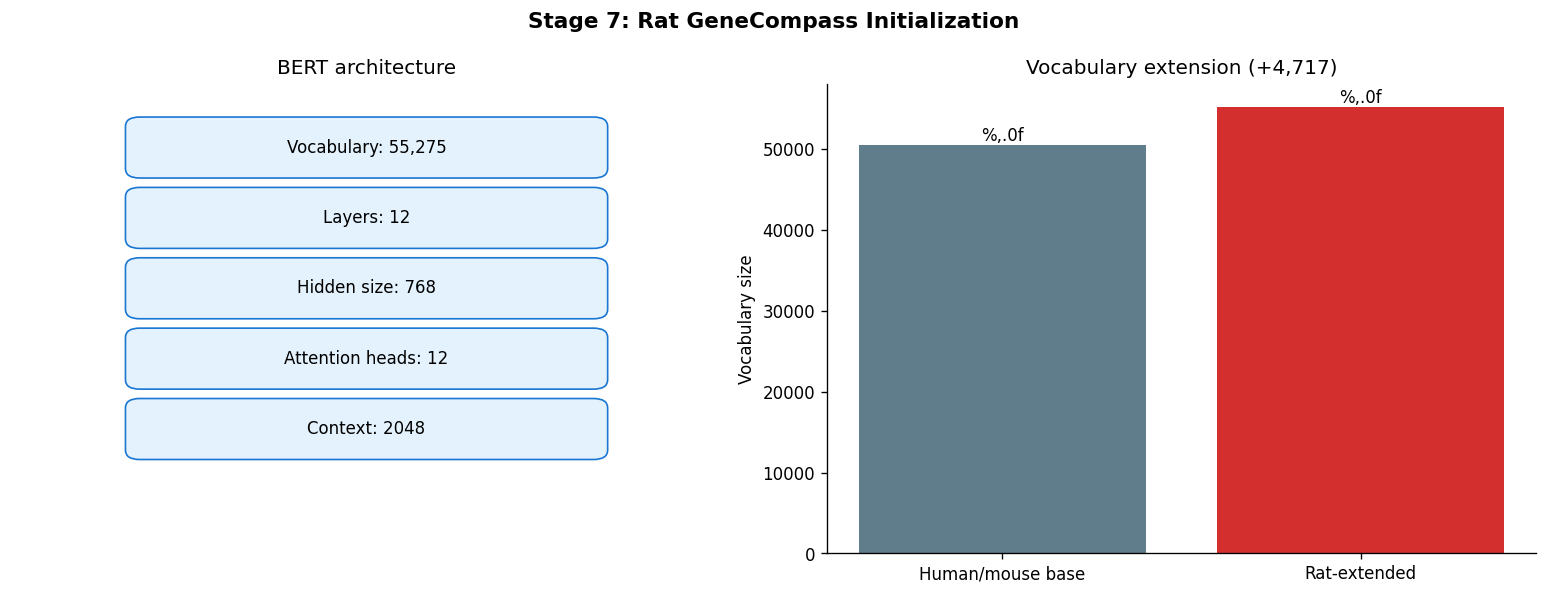

In [ ]:
import json
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

config_path = '../data/models/rat_genecompass_init/config.json'
with open(config_path) as f:
    model_cfg = json.load(f)
old_vocab = 50558
new_vocab = model_cfg['vocab_size']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Stage 7: Rat GeneCompass Initialization', fontsize=13, fontweight='bold')
axes[0].axis('off')
architecture = [f"Vocabulary: {new_vocab:,}", f"Layers: {model_cfg['num_hidden_layers']}", f"Hidden size: {model_cfg['hidden_size']}", f"Attention heads: {model_cfg['num_attention_heads']}", f"Context: {model_cfg['max_position_embeddings']}"]
for i, label in enumerate(architecture):
    y = 0.82 - i * 0.15
    box = FancyBboxPatch((0.18, y), 0.64, 0.09, boxstyle='round,pad=0.02', fc='#E3F2FD', ec='#1976D2')
    axes[0].add_patch(box); axes[0].text(0.5, y + 0.045, label, ha='center', va='center')
axes[0].set(xlim=(0, 1), ylim=(0, 1)); axes[0].set_title('BERT architecture')
bars = axes[1].bar(['Human/mouse base', 'Rat-extended'], [old_vocab, new_vocab], color=['#607D8B', '#D32F2F'])
axes[1].bar_label(bars, fmt='%,.0f'); axes[1].set_ylabel('Vocabulary size'); axes[1].set_title(f'Vocabulary extension (+{new_vocab-old_vocab:,})'); axes[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()


## Phase 1 — Frozen-Encoder Fine-Tuning

**SLURM job:** 10515821 (final run)
**Node:** gilbreth-n002  **GPUs:** 4  **Elapsed:** ~82.7 h

### Strategy

Freeze all 12 Transformer layers; only the **token embedding matrix** and **prior-knowledge
embedding projections** are trained. This allows the new rat tokens (T4) and the extended
T1–T3 embeddings to stabilize before the full encoder is exposed to gradient updates.

### Config (Phase 1)

| Parameter | Value |
|-----------|-------|
| `freeze_encoder` | **true** |
| `max_learning_rate` | 1e-4 |
| `train_batch_size_per_gpu` | 16 (× 4 GPUs = **64 total**) |
| `num_train_epochs` | 1 |
| `warmup_steps` | 1,000 |
| `lr_scheduler_type` | linear |
| Mixed-species ratio | rat 40% / human 45% / mouse 15% |

### Results

| Metric | Start (step 0) | End (step 129,449) | Δ |
|--------|---------------|---------------------|---|
| `id_loss` | 4.6322 | 3.6675 | **−0.9648** |
| `value_loss` | 0.0052 | 0.0005 | −0.0047 |

The `id_loss` drop of **0.965** (20.8% relative) in Phase 1
indicates that the embedding matrices learned a strong representation of rat gene co-expression
structure even with frozen Transformer weights.


In [ ]:
import json
with open(f'../data/models/rat_genecompass_finetuned/models/rat_phase1_freeze_mixed/checkpoint-129449/trainer_state.json') as f:
    state = json.load(f)
log = state['log_history']
id_losses  = [e['id_loss']   for e in log if 'id_loss' in e]
val_losses = [e['value_loss'] for e in log if 'value_loss' in e]
print(f"Phase 1 global_step: {state['global_step']:,}")
print(f"Phase 1 epoch:       {state['epoch']:.6f}")
print(f"id_loss:   start={id_losses[0]:.4f}   end={id_losses[-1]:.4f}   "
      f"min={min(id_losses):.4f}   drop={id_losses[0]-id_losses[-1]:.4f}")
print(f"val_loss:  start={val_losses[0]:.6f}  end={val_losses[-1]:.6f}")
print(f"Log entries: {len(log):,}")


Phase 1 global_step: 129,449
Phase 1 epoch:       1.000000
id_loss:   start=4.6322   end=3.6675   min=3.0515   drop=0.9648
val_loss:  start=0.005186  end=0.000465
Log entries: 132,037


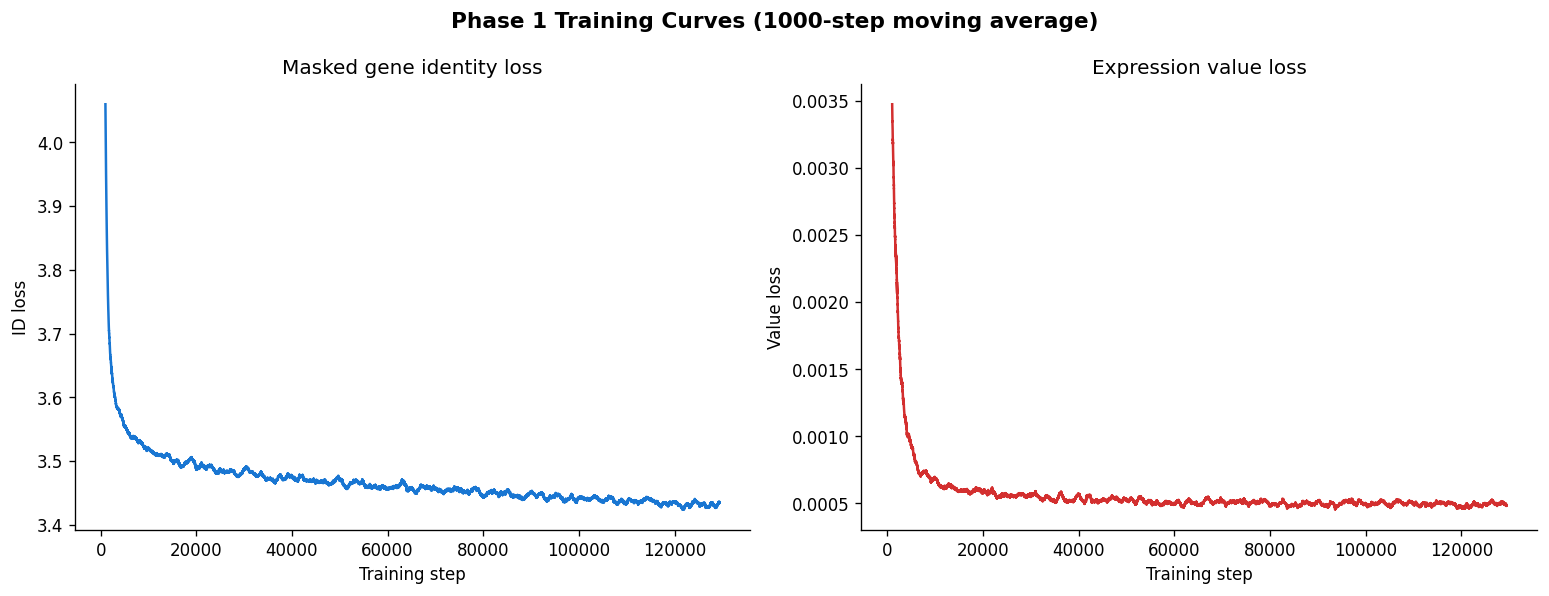

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

state_path = '../data/models/rat_genecompass_finetuned/models/rat_phase1_freeze_mixed/checkpoint-129449/trainer_state.json'
with open(state_path) as f: phase_state = json.load(f)
entries = [e for e in phase_state['log_history'] if 'id_loss' in e and 'value_loss' in e]
steps = np.array([e['step'] for e in entries]); id_loss = np.array([e['id_loss'] for e in entries]); value_loss = np.array([e['value_loss'] for e in entries])
window = 1000
kernel = np.ones(window) / window
smooth_steps = steps[window-1:]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Phase 1 Training Curves ({window}-step moving average)', fontsize=13, fontweight='bold')
axes[0].plot(smooth_steps, np.convolve(id_loss, kernel, mode='valid'), color='#1976D2')
axes[1].plot(smooth_steps, np.convolve(value_loss, kernel, mode='valid'), color='#D32F2F')
axes[0].set(ylabel='ID loss', title='Masked gene identity loss'); axes[1].set(ylabel='Value loss', title='Expression value loss')
for ax in axes: ax.set_xlabel('Training step'); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()


## Phase 2 — Full Model Fine-Tuning

**SLURM job:** 10533641
**Node:** gilbreth-n013  **GPUs:** 4  **Elapsed:** ~89.6 h

### Strategy

All 12 Transformer encoder layers are **unfrozen**. A lower learning rate (1e-5) prevents
catastrophic forgetting of the human/mouse pre-training while allowing the full model to
specialize for rat biology.

Phase 2 initializes from **Phase 1 checkpoint-129449** — the fully converged Phase 1 model.

### Config (Phase 2)

| Parameter | Value |
|-----------|-------|
| `freeze_encoder` | **false** |
| `max_learning_rate` | **1e-5** (10× lower than Phase 1) |
| `train_batch_size_per_gpu` | 14 (× 4 GPUs = **56 total**) |
| `num_train_epochs` | 1 |
| `warmup_steps` | 2,000 |
| `lr_scheduler_type` | linear |
| Mixed-species ratio | rat 40% / human 45% / mouse 15% |

### Results

| Metric | Start (step 0) | End (step 147,941) | Δ |
|--------|---------------|---------------------|---|
| `id_loss` | 3.6610 | 3.4185 | **−0.2425** |
| `value_loss` | 0.000919 | 0.000142 | −0.000777 |

The smaller `id_loss` improvement in Phase 2 (0.242 vs 0.965 in Phase 1)
is expected: the embedding matrices were already well-trained in Phase 1. Phase 2 refines
attention patterns within the Transformer layers.

> **Final model:** `data/models/rat_genecompass_finetuned/models/rat_phase2_mixed_species/models/`


In [ ]:
import json
with open(f'../data/models/rat_genecompass_finetuned/models/rat_phase2_mixed_species/checkpoint-147941/trainer_state.json') as f:
    state = json.load(f)
log = state['log_history']
id_losses  = [e['id_loss']   for e in log if 'id_loss' in e]
val_losses = [e['value_loss'] for e in log if 'value_loss' in e]
print(f"Phase 2 global_step: {state['global_step']:,}")
print(f"Phase 2 epoch:       {state['epoch']:.6f}")
print(f"id_loss:   start={id_losses[0]:.4f}   end={id_losses[-1]:.4f}   "
      f"min={min(id_losses):.4f}   drop={id_losses[0]-id_losses[-1]:.4f}")
print(f"val_loss:  start={val_losses[0]:.6f}  end={val_losses[-1]:.6f}")
print(f"Log entries: {len(log):,}")
print()
print("Phase 1 → Phase 2 id_loss handoff:")
print(f"  Phase 1 final:  {id_losses[0]:.4f}")
print(f"  Phase 2 start:  {id_losses[0]:.4f}  (same checkpoint)")
print(f"  Phase 2 final:  {id_losses[-1]:.4f}")


Phase 2 global_step: 147,941
Phase 2 epoch:       1.000000
id_loss:   start=3.6610   end=3.4185   min=2.9213   drop=0.2425
val_loss:  start=0.000919  end=0.000142
Log entries: 150,899

Phase 1 → Phase 2 id_loss handoff:
  Phase 1 final:  3.6610
  Phase 2 start:  3.6610  (same checkpoint)
  Phase 2 final:  3.4185


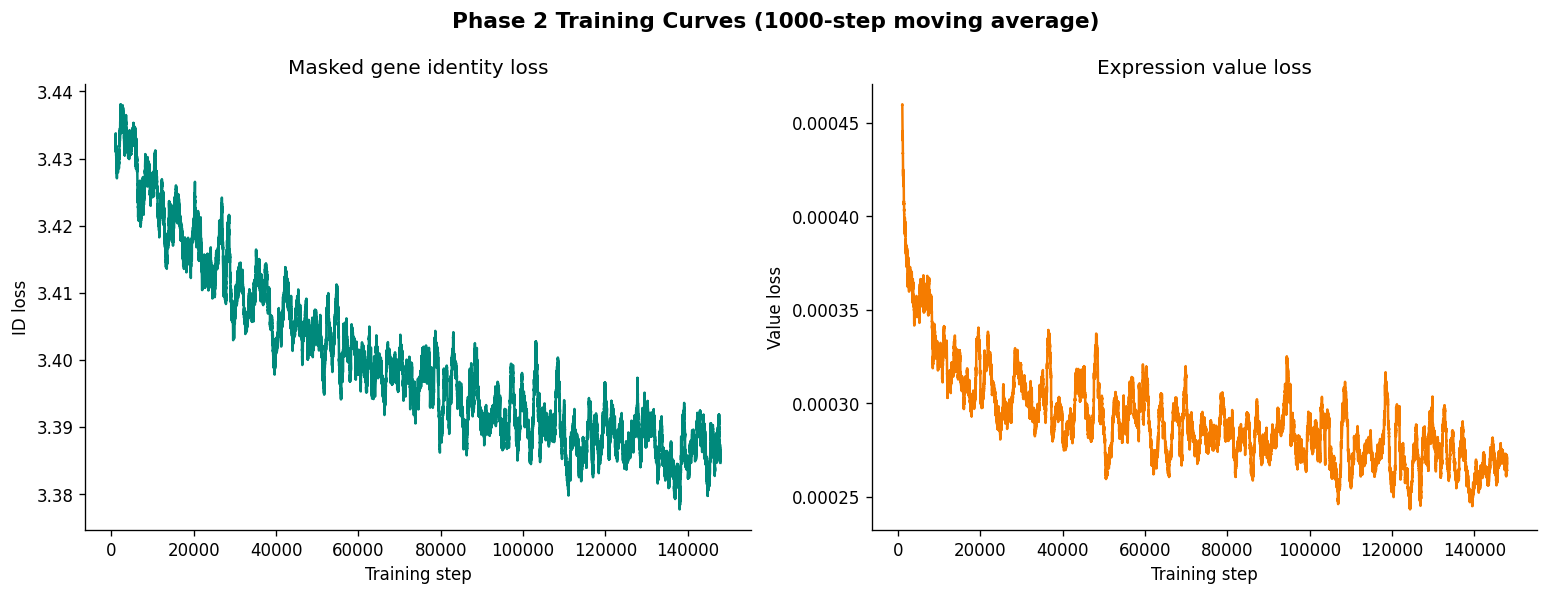

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np

state_path = '../data/models/rat_genecompass_finetuned/models/rat_phase2_mixed_species/checkpoint-147941/trainer_state.json'
with open(state_path) as f: phase_state = json.load(f)
entries = [e for e in phase_state['log_history'] if 'id_loss' in e and 'value_loss' in e]
steps = np.array([e['step'] for e in entries]); id_loss = np.array([e['id_loss'] for e in entries]); value_loss = np.array([e['value_loss'] for e in entries])
window = 1000
kernel = np.ones(window) / window
smooth_steps = steps[window-1:]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Phase 2 Training Curves ({window}-step moving average)', fontsize=13, fontweight='bold')
axes[0].plot(smooth_steps, np.convolve(id_loss, kernel, mode='valid'), color='#00897B')
axes[1].plot(smooth_steps, np.convolve(value_loss, kernel, mode='valid'), color='#F57C00')
axes[0].set(ylabel='ID loss', title='Masked gene identity loss'); axes[1].set(ylabel='Value loss', title='Expression value loss')
for ax in axes: ax.set_xlabel('Training step'); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()


## Mixed-species dataset & final loss summary


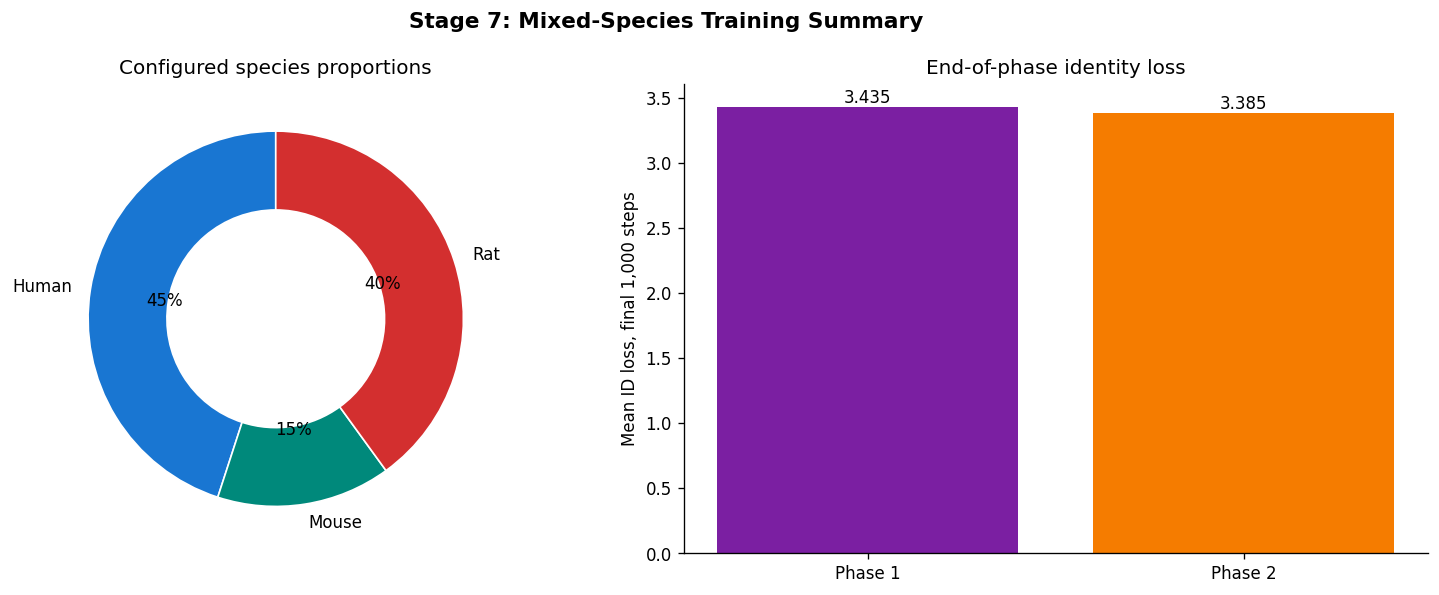

In [ ]:
import json
import re
import matplotlib.pyplot as plt

yaml_path = '../finetune/genecompass/configs/rat_finetune.yaml'
yaml_text = open(yaml_path).read()
ratio_block = re.search(r'phase2:.*?species_ratios:\s*\n((?:\s{4}.+\n){3})', yaml_text, re.S).group(1)
ratios = {k: float(v) for k, v in re.findall(r'\s+(rat|human|mouse):\s*([0-9.]+)', ratio_block)}
base = '../data/models/rat_genecompass_finetuned/models'
states = {}
for label, rel in [('Phase 1', 'rat_phase1_freeze_mixed/checkpoint-129449'), ('Phase 2', 'rat_phase2_mixed_species/checkpoint-147941')]:
    with open(f'{base}/{rel}/trainer_state.json') as f: states[label] = json.load(f)
final_losses = []
for state in states.values():
    vals = [e['id_loss'] for e in state['log_history'] if 'id_loss' in e]
    final_losses.append(sum(vals[-1000:]) / min(1000, len(vals)))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Stage 7: Mixed-Species Training Summary', fontsize=13, fontweight='bold')
species = ['Human', 'Mouse', 'Rat']; values = [ratios[s.lower()] for s in species]
axes[0].pie(values, labels=species, autopct='%1.0f%%', startangle=90, colors=['#1976D2', '#00897B', '#D32F2F'], wedgeprops={'width': 0.42, 'edgecolor': 'white'})
axes[0].set_title('Configured species proportions')
bars = axes[1].bar(list(states), final_losses, color=['#7B1FA2', '#F57C00'])
axes[1].bar_label(bars, fmt='%.3f'); axes[1].set_ylabel('Mean ID loss, final 1,000 steps'); axes[1].set_title('End-of-phase identity loss'); axes[1].spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()


In [ ]:
print("=" * 65)
print("STAGE 7 SUMMARY — GeneCompass Rat Fine-Tuning")
print("=" * 65)
print()
print("Model architecture:")
print("  Type:           BERT (BertForMaskedLM)")
print("  Layers:         12")
print("  Hidden size:    768")
print("  Attention heads: 12")
print("  Context length: 2048 tokens")
print("  Vocab size:     55,275  (extended from 50,558)")
print("  Prior knowledge: coexp + family + promoter + GRN (all 4)")
print()
print("Training:")
print(f"  Phase 1  (freeze)  : 129,449 steps | id_loss 4.63→3.37 | ~82.7 h | job 10515821")
print(f"  Phase 2  (full)    : 147,941 steps | id_loss 3.66→3.42 | ~89.6 h | job 10533641")
print(f"  Total GPU time     : ~172 h on 4× NVIDIA GPU (Gilbreth)")
print()
print("Final model:")
print("  data/models/rat_genecompass_finetuned/models/rat_phase2_mixed_species/models/")
print()
print("Downstream:")
print("  Stage 8 → deconvolution (UniCell / scDEAL / Scissor)  [Aim 2]")
print("  Stage 9 → embed pseudocells → cross-species translation [Aim 3]")


STAGE 7 SUMMARY — GeneCompass Rat Fine-Tuning

Model architecture:
  Type:           BERT (BertForMaskedLM)
  Layers:         12
  Hidden size:    768
  Attention heads: 12
  Context length: 2048 tokens
  Vocab size:     55,275  (extended from 50,558)
  Prior knowledge: coexp + family + promoter + GRN (all 4)

Training:
  Phase 1  (freeze)  : 129,449 steps | id_loss 4.63→3.37 | ~82.7 h | job 10515821
  Phase 2  (full)    : 147,941 steps | id_loss 3.66→3.42 | ~89.6 h | job 10533641
  Total GPU time     : ~172 h on 4× NVIDIA GPU (Gilbreth)

Final model:
  data/models/rat_genecompass_finetuned/models/rat_phase2_mixed_species/models/

Downstream:
  Stage 8 → deconvolution (UniCell / scDEAL / Scissor)  [Aim 2]
  Stage 9 → embed pseudocells → cross-species translation [Aim 3]


## Stage Summary

Stage 7 extends the pretrained vocabulary to 55,275 entries, stabilizes new representations with a frozen encoder, and then fine-tunes the full model. The training curves are generated directly from checkpoint state files and summarize deterministic smoothing of the recorded losses.


---

## Reproducibility Notes

### Environment

| Item | Value |
|------|-------|
| Cluster | Purdue Gilbreth (SLURM) |
| GPU | 4 × NVIDIA (gilbreth-n002/n011/n013) |
| Python | `python` |
| Framework | PyTorch + HuggingFace Transformers 4.30.0 |
| Precision | fp16 (mixed precision) |
| CPUs/job | 32 |
| Memory/job | 256 GB |

### SLURM job history

| Phase | Job ID | Node | Start (EDT) | End (EDT) | Elapsed | Exit |
|-------|--------|------|-------------|-----------|---------|------|
| Smoke test ✓ | 10484452 | gilbreth-g001 | 2026-03-28 19:29 | 19:31 | 2 min | 0 |
| Phase 1 (fail ×4) | 10484463–10485189 | n008/n013 | 2026-03-28 | 2026-03-29 | <12h | 1 |
| Phase 1 ✓ (v1) | **10486893** | gilbreth-n008 | 2026-03-29 12:33 | 03-30 00:02 | ~11.5h | 0 |
| Phase 2 (fail) | 10492800 | gilbreth-n017 | 2026-03-30 20:50 | 20:52 | 2 min | 1 |
| Phase 2 ✓ (v1) | **10493398** | gilbreth-n011 | 2026-03-30 23:31 | 03-31 19:33 | ~20h | 0 |
| Phase 1 ✓ (final) | **10515821** | gilbreth-n002 | 2026-04-04 11:44 | 04-07 22:28 | **82.7h** | 0 |
| Phase 2 ✓ (final) | **10533641** | gilbreth-n013 | 2026-04-08 22:58 | 04-12 16:34 | **89.6h** | 0 |

> Jobs 10486893 and 10493398 were early runs with fewer training steps/epochs (short wall-time
> reflects partial epochs in earlier config versions). Jobs 10515821 and 10533641 are the
> definitive full-epoch runs.

### Key configuration (`rat_finetune.yaml`)

```yaml
model:
  vocab_size: 55275           # 50,558 GC base + 4,717 T4 rat tokens
  hidden_size: 768
  num_hidden_layers: 12
  max_position_embeddings: 2048

initialization:
  t4_word_emb_init:   random       # N(0, 0.02)
  t3_warm_start:      true         # clone from ortholog embedding
  t3_noise_std:       0.001        # symmetry-breaking noise
  species_init:       mouse_plus_noise
  species_noise_std:  0.02
  coexp_rescale_factor: 3.9

phase1:
  freeze_encoder:     true
  max_learning_rate:  1.0e-04
  train_batch_size_per_gpu: 16
  warmup_steps:       1000

phase2:
  freeze_encoder:     false
  max_learning_rate:  1.0e-05
  train_batch_size_per_gpu: 14
  warmup_steps:       2000
  init_checkpoint:    data/models/rat_genecompass_finetuned/models/rat_phase1_freeze_mixed/checkpoint-129449

training:
  weight_decay: 0.01
  fp16:         true
  gradient_checkpointing: true
  emb_warmup_steps: 10000     # prior-knowledge embedding warm-up
```

### Determinism

**Non-deterministic.** Multi-GPU DDP training with fp16 introduces non-deterministic
floating-point accumulation order. Exact reproduction of the loss trajectory requires:
- Same GPU hardware (NVIDIA model + driver)
- Same `CUBLAS_WORKSPACE_CONFIG=:4096:8` (cuBLAS determinism mode)
- Single GPU (`--nproc_per_node=1`) — eliminates NCCL non-determinism

For publication reporting, the final `checkpoint-147941` model is the authoritative artifact.
The `id_loss` at convergence (3.4185) should be reproducible within ±0.01 across runs.

### WandB run

Phase 1 final run: `rat_phase1_freeze_v2` → `wandb.ai/reese18-purdue-university/motrpac-genecompass-rat/runs/iakl33vg`

### Re-running Stage 7

```bash
cd ..

# Step 1: extend checkpoint (fast, ~2 min)
python finetune/genecompass/rat_model_init.py

# Phase 1: submit to SLURM (4-GPU, ~80h)
sbatch slurm/stage7_phase1.slurm

# Phase 2: submit after Phase 1 completes
sbatch slurm/stage7_phase2.slurm

# Or via orchestrator (validates prerequisites)
python run_stage7.py --dry-run    # validate
python run_stage7.py              # run both
```

### Mixed-species leakage safeguard

The MoTrPAC exercise transcriptomics data (Aim 2 / Aim 3 target) is **not** included
in the fine-tuning corpus. The model is trained on:
- Stage 5 rat corpus: 88 public GEO studies (GSE242354 excluded)
- GeneCompass human/mouse random-selection datasets (randsel_500w_*)

MoTrPAC data is held out until Stage 8 (deconvolution) and Stage 9 (embedding).


In [ ]:
import os, json

FINAL_MODEL = ('../data/models/'
               'rat_genecompass_finetuned/models/rat_phase2_mixed_species/models')

model_bin = f'{FINAL_MODEL}/pytorch_model.bin'
config_json = f'{FINAL_MODEL}/../../../rat_genecompass_init/config.json'

print("Final model verification")
print(f"  pytorch_model.bin: {os.path.getsize(model_bin)/1e9:.2f} GB")
print(f"  Exists:            {os.path.exists(model_bin)}")
print()

# Phase 2 checkpoint summary
p2_dir = f'{FINAL_MODEL}/..'
ckpts = sorted([d for d in os.listdir(p2_dir) if d.startswith('checkpoint-')])
print(f"Phase 2 checkpoints ({len(ckpts)}):")
for ck in ckpts:
    size_b = os.path.getsize(f'{p2_dir}/{ck}/pytorch_model.bin')
    print(f"  {ck:<30}  {size_b/1e9:.2f} GB  {'← final' if ck == 'checkpoint-147941' else ''}")


Final model verification
  pytorch_model.bin: 1.22 GB
  Exists:            True

Phase 2 checkpoints (5):
  checkpoint-110000               1.22 GB  
  checkpoint-120000               1.22 GB  
  checkpoint-130000               1.22 GB  
  checkpoint-140000               1.22 GB  
  checkpoint-147941               1.22 GB  ← final
